# ============================================================
# 03 — ACCIÓN Y ACUMULACIÓN
# ============================================================

# En este experimento una acción comienza a actuar
# progresivamente sobre una trayectoria.
#
# A diferencia del 02, aquí no solo definimos acciones:
# observamos qué ocurre cuando una acción modifica
# una trayectoria.
#
# Concepto principal:
# ACUMULACIÓN = una influencia que aumenta progresivamente.
#
# Pregunta:
# ¿Qué ocurre cuando una acción deja una huella
# sobre lo que viene después?

In [1]:
# ============================================================
# CELDA 02 — HERRAMIENTAS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

numpy → para trabajar con números y construir la trayectoria.
matplotlib → para visualizarla.

Todavía no hacemos ninguna acción. Primero vamos a construir la trayectoria sobre la que después actuará la acumulación.

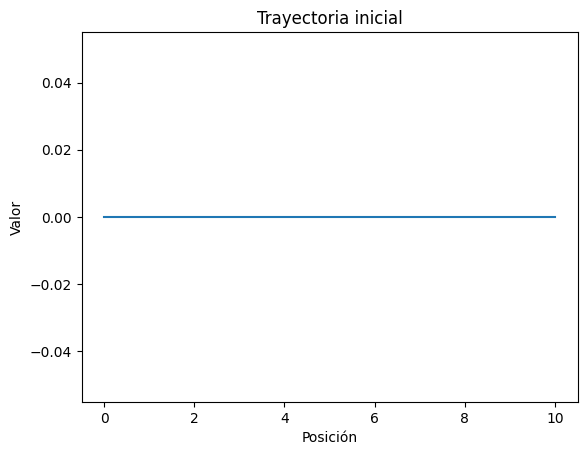

In [2]:
# ============================================================
# CELDA 03 — CREAR UNA TRAYECTORIA
# ============================================================

# Creamos una secuencia de posiciones.
x = np.linspace(0, 10, 200)

# Por ahora la trayectoria es una línea simple.
y = np.zeros_like(x)

# Visualizamos la trayectoria inicial.
plt.plot(x, y)
plt.title("Trayectoria inicial")
plt.xlabel("Posición")
plt.ylabel("Valor")
plt.show()

Aquí todavía no ocurre ninguna acción.

Hay una trayectoria inicial:

────────────────────────

Esto  sirve como estado de partida.

En la siguiente celda se creará la función de acumulación que actuará sobre un tramo de esta trayectoria.

np.linspace() no significa “crear una trayectoria”.

Significa simplemente:

crear una serie de números distribuidos uniformemente entre un inicio y un final.

Por ejemplo:

np.linspace(0, 10, 5)

produce:

0 → 2.5 → 5 → 7.5 → 10

En el 03 usamos:

x = np.linspace(0, 10, 200)

porque se necesitan 200 posiciones entre 0 y 10 para construir nuestro espacio de trabajo.

Luego se hace:

y = np.zeros_like(x)

y se obtiene:

x:  0 ─────────────────────── 10
y:  0 ─────────────────────── 0

Entonces:

linspace = crea posiciones/puntos

y = valores que se ponen sobre esas posiciones

Y cuando se modifican esos valores:

antes:

────────────────────

después:

──────────╱─────────

ahí es una trayectoria.

Por eso, para estos experimentos, hay que recordar:

np.linspace() = repartir puntos regularmente en un intervalo.

No una trayectoria. La trayectoria aparece cuando se usan esos puntos para representar un recorrido o evolución.

CELDA 04 — Definir la acumulación

In [3]:
# ============================================================
# CELDA 04 — ACUMULACIÓN
# ============================================================

def aplicar_acumulacion(y, inicio, fin, intensidad, memoria):
    """
    Aplica una influencia que aumenta progresivamente
    sobre un tramo de la trayectoria.
    """

    # Copiamos la trayectoria original
    y_nuevo = y.copy()

    # Creamos una progresión desde 0 hasta 1
    tramo = np.linspace(0, 1, fin - inicio)

    # La influencia aumenta progresivamente
    acumulacion = intensidad * tramo * memoria

    # Aplicamos la acumulación solamente en el tramo elegido
    y_nuevo[inicio:fin] += acumulacion

    return y_nuevo

y            → trayectoria
inicio       → dónde comienza la acción
fin          → dónde termina
intensidad   → cuánto afecta
memoria      → cuánto se conserva el efecto

Y hace:

trayectoria
     ↓
elige un tramo
     ↓
influencia pequeña
     ↓
influencia mayor
     ↓
influencia máxima
     ↓
nueva trayectoria

Todavía no se ejecuta. En la siguiente celda se le darán valores concretos y se verá qué produce.

In [4]:
# ============================================================
# CELDA 05 — APLICAR LA ACUMULACIÓN
# ============================================================

inicio = 50
fin = 150

intensidad = 2
memoria = 1

y_acumulada = aplicar_acumulacion(
    y,
    inicio,
    fin,
    intensidad,
    memoria
)

El resultado queda guardado en:

y_acumulada

Es decir:

y
↓
aplicar_acumulacion()
↓
y_acumulada

Todavía no se visualiza

CELDA 06 — Visualizar la transformación

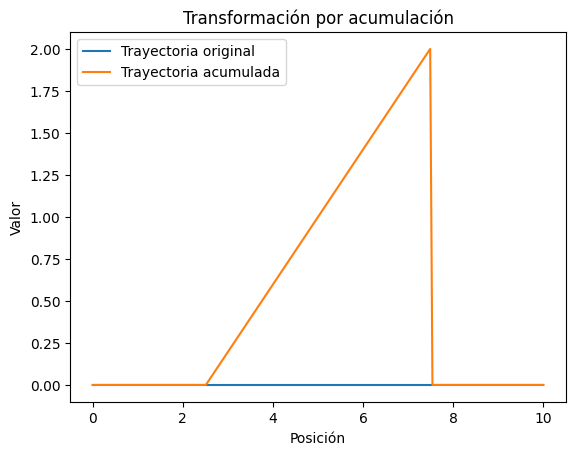

In [5]:
# ============================================================
# CELDA 06 — VISUALIZAR
# ============================================================

plt.plot(x, y, label="Trayectoria original")
plt.plot(x, y_acumulada, label="Trayectoria acumulada")

plt.title("Transformación por acumulación")
plt.xlabel("Posición")
plt.ylabel("Valor")
plt.legend()
plt.show()

01 → condiciones
02 → operaciones
03 → una operación empieza a producir una transformación progresiva.

Y en el 03 ya aparecieron concretamente:

Acción → Acumulación → Trayectoria → Transformación

La siguiente celda debería ser interesante: hacer variar memoria para observar qué cambia realmente.

CELDA 07 — Cambiar la memoria

Ahora vamos a hacer una comparación muy simple: qué pasa cuando cambiamos

In [6]:
# ============================================================
# CELDA 07 — CAMBIAR LA MEMORIA
# ============================================================

memoria_baja = 0.5
memoria_alta = 2

y_memoria_baja = aplicar_acumulacion(
    y,
    inicio,
    fin,
    intensidad,
    memoria_baja
)

y_memoria_alta = aplicar_acumulacion(
    y,
    inicio,
    fin,
    intensidad,
    memoria_alta
)

Aquí no cambiamos la trayectoria ni la intensidad.

Solo cambiamos:

memoria = 0.5
memoria = 2

Por lo tanto podremos observar:

¿Qué diferencia produce que la influencia anterior tenga más o menos peso?

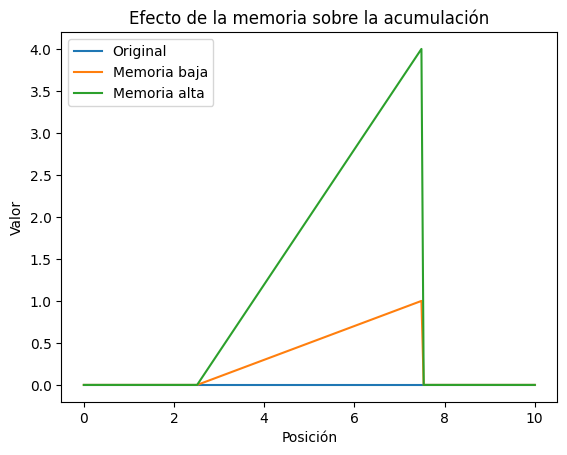

In [7]:
# ============================================================
# CELDA 08 — COMPARAR MEMORIA
# ============================================================

plt.plot(x, y, label="Original")
plt.plot(x, y_memoria_baja, label="Memoria baja")
plt.plot(x, y_memoria_alta, label="Memoria alta")

plt.title("Efecto de la memoria sobre la acumulación")
plt.xlabel("Posición")
plt.ylabel("Valor")
plt.legend()
plt.show()

CELDA 09 — Comparar intensidad y memoria

Aquí distinguimos dos conceptos que hasta ahora pueden parecer iguales:

Intensidad → cuánto afecta la acción.
Memoria → cuánto pesa esa influencia acumulada.

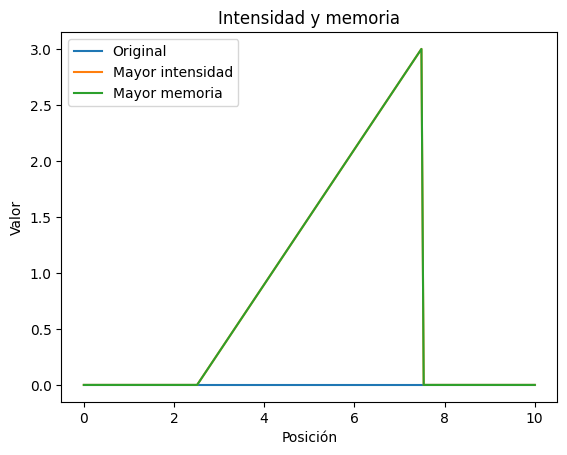

In [8]:
# ============================================================
# CELDA 09 — INTENSIDAD Y MEMORIA
# ============================================================

y_intensidad = aplicar_acumulacion(
    y,
    inicio,
    fin,
    intensidad=3,
    memoria=1
)

y_memoria = aplicar_acumulacion(
    y,
    inicio,
    fin,
    intensidad=1,
    memoria=3
)

plt.plot(x, y, label="Original")
plt.plot(x, y_intensidad, label="Mayor intensidad")
plt.plot(x, y_memoria, label="Mayor memoria")

plt.title("Intensidad y memoria")
plt.xlabel("Posición")
plt.ylabel("Valor")
plt.legend()
plt.show()

03 — Trenzas + combinaciones

Una combinación empieza a actuar sobre una trenza.
Observamos qué comportamiento produce.
La acumulación/memoria pueden aparecer como fenómenos simples del comportamiento, no como el tema principal.

Así que no seguiría con intensidad vs. memoria

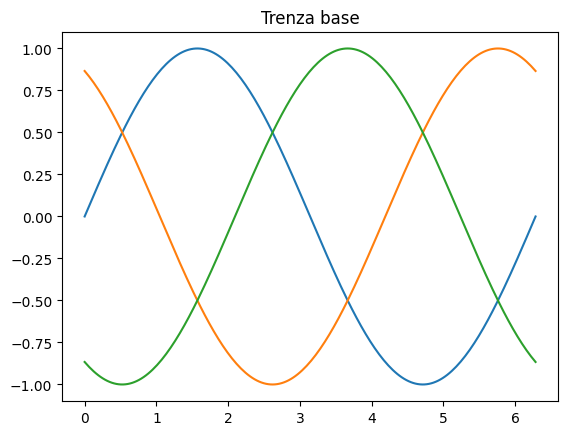

In [9]:
# ============================================================
# CELDA 07 — TRENZA BASE
# ============================================================

# Creamos una trenza simple a partir de tres hilos.
t = np.linspace(0, 2 * np.pi, 200)

hilo_1 = np.sin(t)
hilo_2 = np.sin(t + 2 * np.pi / 3)
hilo_3 = np.sin(t + 4 * np.pi / 3)

# Visualizamos la trenza.
plt.plot(t, hilo_1)
plt.plot(t, hilo_2)
plt.plot(t, hilo_3)

plt.title("Trenza base")
plt.show()

La siguiente celda será donde construimos una combinación del diccionario, por ejemplo:

B + M + R

CELDA 08 — Elegir una combinación

In [10]:
# ============================================================
# CELDA 08 — COMBINACIÓN
# ============================================================

# Elegimos una combinación del diccionario.
combinacion = ["B", "M", "R"]

# B = Bifurcar
# M = Mapear
# R = Reconfigurar

print("Combinación seleccionada:", combinacion)

Combinación seleccionada: ['B', 'M', 'R']


CELDA 09 — Definir las acciones

In [11]:
# ============================================================
# CELDA 09 — ACCIONES
# ============================================================

acciones = {
    "B": "Bifurcar",
    "M": "Mapear",
    "R": "Reconfigurar"
}

for codigo in combinacion:
    print(codigo, "→", acciones[codigo])

B → Bifurcar
M → Mapear
R → Reconfigurar


en nuestro experimento representa cuánto peso tiene la influencia acumulada sobre la trayectoria.

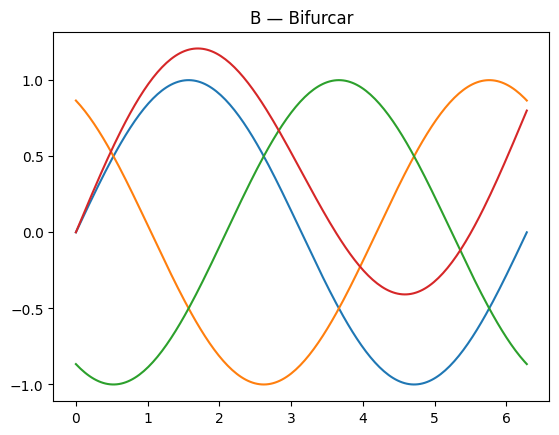

In [13]:
# CELDA 10 — Bifurcar la

# ============================================================
# CELDA 10 — BIFURCAR
# ============================================================

# Tomamos el primer hilo de la trenza
# y creamos una segunda trayectoria a partir de él.

bifurcacion = hilo_1.copy()

# Desplazamos progresivamente la nueva trayectoria
bifurcacion += np.linspace(0, 0.8, len(bifurcacion))

# Visualizamos la trenza y la bifurcación
plt.plot(t, hilo_1)
plt.plot(t, hilo_2)
plt.plot(t, hilo_3)
plt.plot(t, bifurcacion)

plt.title("B — Bifurcar")
plt.show()

hilo
  │
  ├── hilo original
  │
  └── nueva trayectoria

Bifurcar = una trayectoria se divide en otra.

Todavía no se aplica M ni R. Primero se hace que cada acción pueda verse por separado.

CELDA 11 — Mapear

Ahora se crea una versión muy simple de M = Mapear: tomamos la trayectoria bifurcada y se lleva a otro rango.

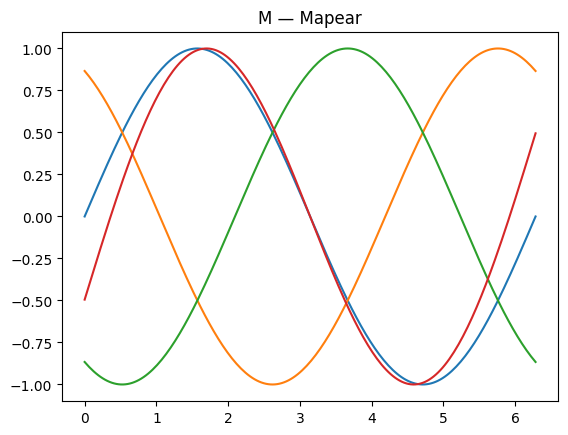

In [14]:
# ============================================================
# CELDA 11 — MAPEAR
# ============================================================

# Tomamos la bifurcación creada anteriormente
# y la transformamos a un nuevo rango.

mapa = np.interp(
    bifurcacion,
    (bifurcacion.min(), bifurcacion.max()),
    (-1, 1)
)

# Visualizamos
plt.plot(t, hilo_1)
plt.plot(t, hilo_2)
plt.plot(t, hilo_3)
plt.plot(t, mapa)

plt.title("M — Mapear")
plt.show()

Bifurcar → crea una nueva trayectoria.
Mapear → transforma los valores de esa trayectoria a otro rango.

Todavía falta R = Reconfigurar.
Ahora hacer R = Reconfigurar de una manera muy simple: cambiar la posición de algunos puntos de la trayectoria.

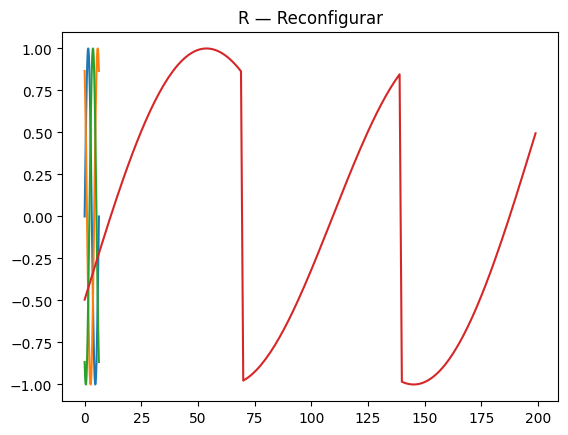

In [15]:
# ============================================================
# CELDA 12 — RECONFIGURAR
# ============================================================

# Copiamos la trayectoria mapeada
reconfigurada = mapa.copy()

# Cambiamos progresivamente una parte de la trayectoria
reconfigurada[70:140] = reconfigurada[70:140][::-1]

# Visualizamos
plt.plot(t, hilo_1)
plt.plot(t, hilo_2)
plt.plot(t, hilo_3)
plt.plot(reconfigurada)

plt.title("R — Reconfigurar")
plt.show()

trayectoria
     ↓
RECONFIGURAR
     ↓
otra organización

Así se tienen las tres acciones por separado:

B — Bifurcar → crea otra trayectoria
M — Mapear → cambia el rango
R — Reconfigurar → cambia la organización

Y ahora viene lo realmente interesante del 03:

hacer que B + M + R ocurran como una combinación, en lugar de observarlas por separado.

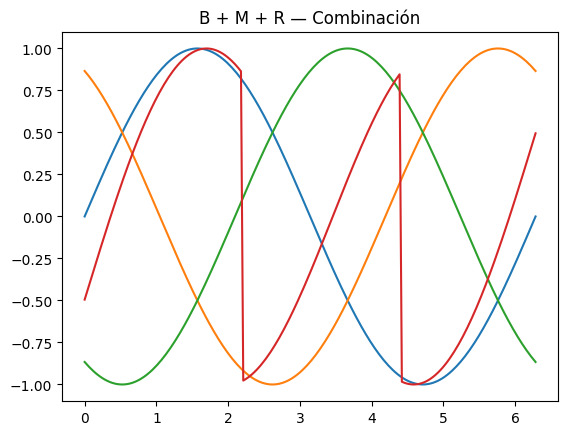

In [16]:
# ============================================================
# CELDA 13 — EJECUTAR LA COMBINACIÓN
# ============================================================

# 1. B — Bifurcar
resultado = hilo_1.copy()
resultado += np.linspace(0, 0.8, len(resultado))

# 2. M — Mapear
resultado = np.interp(
    resultado,
    (resultado.min(), resultado.max()),
    (-1, 1)
)

# 3. R — Reconfigurar
resultado[70:140] = resultado[70:140][::-1]

# Visualizamos el resultado final
plt.plot(t, hilo_1)
plt.plot(t, hilo_2)
plt.plot(t, hilo_3)
plt.plot(t, resultado)

plt.title("B + M + R — Combinación")
plt.show()

CELDA 14 — Canvas limpio con varias combinaciones

Primero generamos varias combinaciones:

CELDA 14 — Cuatro combinaciones con B, M, R

In [17]:
# ============================================================
# CELDA 14 — COMBINACIONES
# ============================================================

combinaciones = [
    ["B", "M", "R"],
    ["B", "R", "M"],
    ["M", "B", "R"],
    ["R", "M", "B"]
]

for combinacion in combinaciones:
    print(" + ".join(combinacion))

B + M + R
B + R + M
M + B + R
R + M + B


CELDA 15 — Cuatro combinaciones nuevas

In [18]:
# ============================================================
# CELDA 15 — NUEVAS COMBINACIONES
# ============================================================

combinaciones_nuevas = [
    ["T", "J", "W"],
    ["B", "T", "J"],
    ["M", "W", "R"],
    ["T", "B", "W"]
]

for combinacion in combinaciones_nuevas:
    print(" + ".join(combinacion))

T + J + W
B + T + J
M + W + R
T + B + W


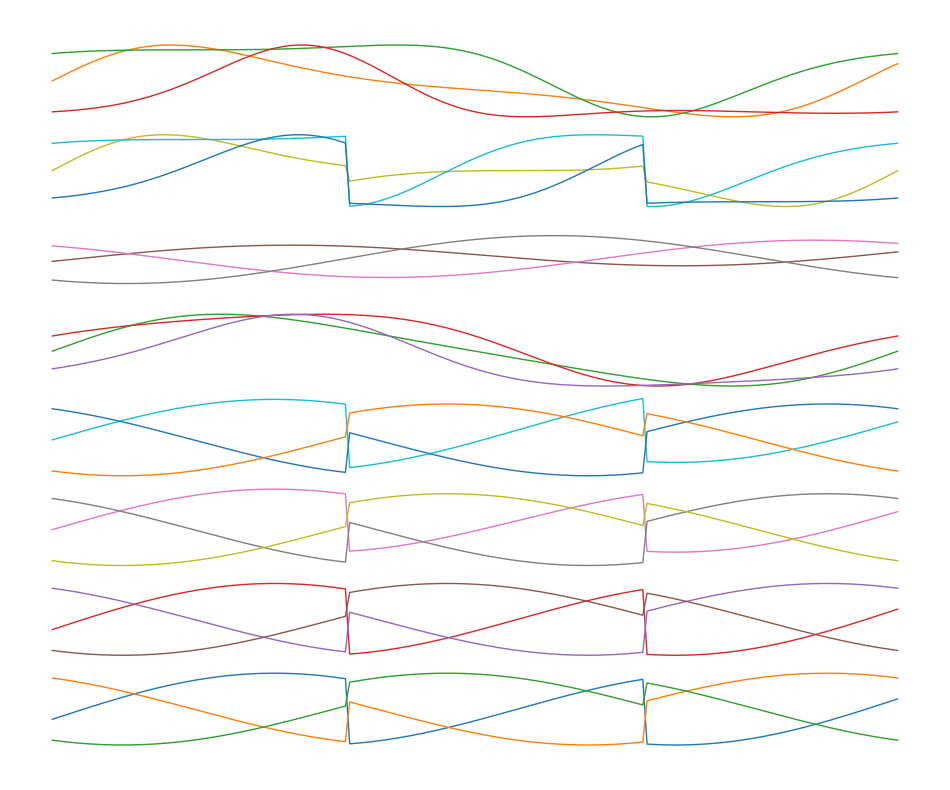

In [21]:
# ============================================================
# CELDA 16 — 8 TRENZAS / CANVAS LIMPIO
# ============================================================

todas_las_combinaciones = (
    combinaciones +
    combinaciones_nuevas
)

plt.figure(figsize=(12, 10))

for i, combinacion in enumerate(todas_las_combinaciones):

    # Posición vertical de esta trenza
    desplazamiento = i * 2.5

    # Tres hilos
    hilo_1 = np.sin(t)
    hilo_2 = np.sin(t + 2 * np.pi / 3)
    hilo_3 = np.sin(t + 4 * np.pi / 3)

    # --------------------------------------------------------
    # Aplicamos la combinación
    # --------------------------------------------------------

    hilos = [hilo_1, hilo_2, hilo_3]

    for accion in combinacion:

        if accion == "B":
            # Bifurcar
            hilos[0] = hilos[0] + np.linspace(0, 0.5, len(t))

        elif accion == "M":
            # Mapear
            for j in range(3):
                hilos[j] = np.interp(
                    hilos[j],
                    (hilos[j].min(), hilos[j].max()),
                    (-1, 1)
                )

        elif accion == "R":
            # Reconfigurar
            for j in range(3):
                hilos[j][70:140] = hilos[j][70:140][::-1]

        elif accion == "T":
            # Transcodificar
            for j in range(3):
                hilos[j] = hilos[j] * (0.8 + j * 0.2)

        elif accion == "J":
            # Juntar
            promedio = sum(hilos) / 3
            for j in range(3):
                hilos[j] = (hilos[j] + promedio) / 2

        elif accion == "W":
            # Warp
            for j in range(3):
                hilos[j] = np.sin(t + hilos[j])

    # --------------------------------------------------------
    # Dibujar los 3 hilos de esta trenza
    # --------------------------------------------------------

    for hilo in hilos:
        plt.plot(
            t,
            hilo + desplazamiento,
            linewidth=1
        )

# Canvas limpio
plt.axis("off")
plt.show()

usar sin() como una materia gráfica simple para experimentar con las trenzas y después dejar que las combinaciones del diccionario la transformen.

Ahora que tenemos las 8 trenzas juntas y más entrelazadas, yo haría una sola cosa más antes de cerrar el 03: identificar visualmente qué combinación produjo cada trenza.

In [22]:
# ============================================================
# CELDA 17 — REGISTRAR LAS COMBINACIONES
# ============================================================

for i, combinacion in enumerate(todas_las_combinaciones, start=1):
    print(
        f"Trenza {i}:",
        " + ".join(combinacion)
    )


Trenza 1: B + M + R
Trenza 2: B + R + M
Trenza 3: M + B + R
Trenza 4: R + M + B
Trenza 5: T + J + W
Trenza 6: B + T + J
Trenza 7: M + W + R
Trenza 8: T + B + W


Las combinaciones del 03 no están siendo calculadas directamente a partir de entropía, ruido y contención.

La relación que se está construyendo es:

01
CONDICIONES
Contención
Ruido
Entropía
       ↓
02
DICCIONARIO
Unidades
Acciones
Combinaciones
       ↓
03
COMPORTAMIENTOS
Combinación
     ↓
actúa sobre
     ↓
Trenza
     ↓
forma / comportamiento

Entonces sí están relacionadas, pero no son la misma capa.

Por ejemplo:

B + M + R

no significa:

B = ruido, M = entropía, R = contención ....NO

Eso sería forzar la relación.

Más bien:

La trenza que estoy transformando ya proviene del conjunto de condiciones explorado en el 01, y ahora el diccionario del 02 me permitió aplicar operaciones diferentes sobre ella.
Desición:

Ruido, entropía y contención son condiciones que exploramos desde el 01; las acciones del diccionario son otra capa.